# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
* Latent variables help us understand influencing factors that cannot be directly observed. With the addition of latent variables, the analysis is no longer linear, but the advantage is that we can get probabilities between 0 and 1, count data, and other kinds of classification stuff.
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
* Because we're making predictions in the form of probabilities, binary and categorical cross entropy are appropriate loss functions. What they do, ultimately, is assess the difference between true labels and predicted probabilies. Low bce/cce means the model is doing well at predictions.
3. True or false, and explain: Logistic regression is a linear model.  
* True, logistic regression is a linear model. It is a linear model because of its parameters.
4. True or false, and explain: Logistic regression cannot be used for classification.
* False, logistic regression can be used for classification. It works for both binary and categorical outcomes, plus hard and soft classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
* No, it does not. Because of the latent variable, the coefficients do not have the same meaning as coefficients in a linear regression.
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
* False, feature engineering in a nonlinear context will help for the same reasons in a linear context. The linearity does not change the need for feature engineering.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
* False, there are scenarios where linear regression would be best to use and where logistic regression would be best. It depends on the context and what kind of predictions are needed, and it doesn't make sense to completely abandon the usual linear models.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
! git clone https://github.com/AngelikaBaloy/undergrad_ml_assignments/

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 242, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 242 (delta 9), reused 2 (delta 2), pack-reused 229 (from 2)
Receiving objects: 100% (242/242), 19.72 MiB | 9.95 MiB/s, done.
Resolving deltas: 100% (100/100), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

In [3]:
# 1. load data
df = pd.read_csv('./undergrad_ml_assignments/data/data.csv', sep=';')
# df.head()
# df.columns

In [4]:
# filtering
df = df.loc[:, ['Debtor', 'Tuition fees up to date',
           'Scholarship holder', 'Age at enrollment',
           'Curricular units 1st sem (approved)',
           'Target']]
df.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [28]:
# missings
df.isna().sum()

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Curricular units 1st sem (approved),0
Target,0


In [5]:
# binary target
df['Target'].value_counts()
mapper = {'Dropout': 1, 'Graduate': 0, 'Enrolled': 0} # dropout is 1, else 0
df['Binary_Target'] = df['Target'].map(mapper)
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Binary_Target
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [6]:
# 2. logistic regression
x = df.loc[:, ['Debtor', 'Tuition fees up to date',
           'Scholarship holder', 'Age at enrollment',
           'Curricular units 1st sem (approved)']]
y = df['Binary_Target']

reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg = reg.fit(x,y)
pd.DataFrame({'Variable':reg.feature_names_in_, 'Coefficient':reg.coef_[0]})

# Predict a higher dropout probability:
#       Debtor, age at enrollment (smaller impact compared to debtor)
# Predict a lower dropout probability:
#       Tuition fees up to date, scholarship holder, curricular units
#       Being up to date on tuition is related to a reduced dropout risk.

,Variable,Coefficient
0,Debtor,0.530334
1,Tuition fees up to date,-2.468833
2,Scholarship holder,-0.944699
3,Age at enrollment,0.057069
4,Curricular units 1st sem (approved),-0.429763


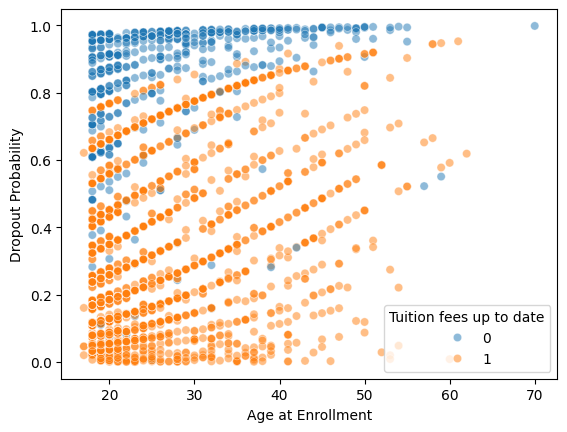

In [42]:
# 3. dropout probabilities
prob = reg.predict_proba(x)
prob = [row[1] for row in prob]
age_at_enroll = x['Age at enrollment']


sns.scatterplot(x=age_at_enroll, y=prob,
                hue=x['Tuition fees up to date'],
                alpha=.5)
plt.xlabel('Age at Enrollment')
plt.ylabel('Dropout Probability')
plt.show()

# Being up to date on tuition seems to reduce dropout probability
# across age groups, as the orange hue takes up the lower portion of
# the plot.
# Being up to date on tuition reduces predicted probability of dropout by
# about 20 (?) percent.


In [43]:
# 4. confusion matrix
y_predict = pd.Series(reg.predict(x))

tab= pd.crosstab(y_predict, df['Binary_Target'])
acc= np.trace(tab)/len(y_predict)
print(f'Confusion matrix:\n {tab}')
print(f'Accuracy: {acc}')

# accuracy is 0.834

Confusion matrix:
 Binary_Target     0    1
row_0                   
0              2752  482
1               251  939
Accuracy: 0.8343128390596745


In [8]:
# 5. linear model with same variables

x = df.loc[:, ['Debtor', 'Tuition fees up to date',
           'Scholarship holder', 'Age at enrollment',
           'Curricular units 1st sem (approved)']]
y = df['Binary_Target']

reg = LinearRegression()
reg = reg.fit(x,y)
y_hat = reg.predict(x)

print(pd.DataFrame({'Variable':reg.feature_names_in_, 'Coefficient':reg.coef_}))

# Convert continuous predictions to binary classes using a threshold (e.g., 0.5)
y_pred_binary = (y_hat >= 0.5).astype(int)

tab= pd.crosstab(y_pred_binary, df['Binary_Target'])
acc= np.trace(tab)/len(y_pred_binary)
print(f'Confusion matrix:\n {tab}')
print(f'Accuracy: {acc}')

# accuracy is 0.833; linear model is very slightly worse at predictions

                              Variable  Coefficient
0                               Debtor     0.079956
1              Tuition fees up to date    -0.390946
2                   Scholarship holder    -0.124911
3                    Age at enrollment     0.009733
4  Curricular units 1st sem (approved)    -0.057672
Confusion matrix:
 Binary_Target     0    1
row_0                   
0              2788  525
1               215  896
Accuracy: 0.8327305605786618


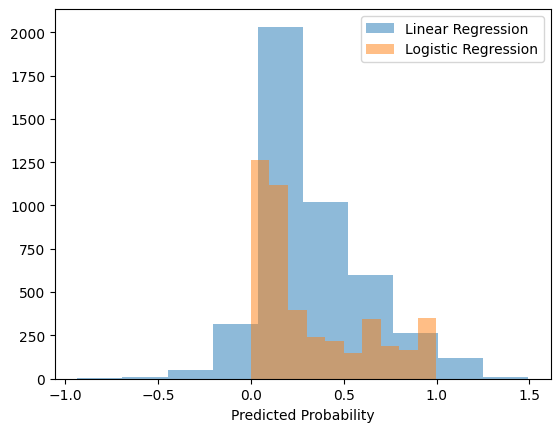

In [48]:
# histogram of predicted probabilities
plt.hist(x=y_hat, alpha=.5, label='Linear Regression')
plt.hist(x=prob, alpha=.5, label='Logistic Regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

In [ ]:
# 6.
# which students are the most at risk of dropping out?
# what kinds of interventions can you imagine that would help at-risk students stay enrolled?

# Students with debt are at most risk of dropping out.
# Helping students manage their debt may help prevent dropouts.

In [6]:
# 7. multinomial logistic regression
x = df.loc[:, ['Debtor', 'Tuition fees up to date',
           'Scholarship holder', 'Age at enrollment',
           'Curricular units 1st sem (approved)']]
y = df['Target'] # grad, dropout, enrolled

reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg = reg.fit(x,y)
pd.DataFrame({'Variable':reg.feature_names_in_, 'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,Debtor,0.361978
1,Tuition fees up to date,-1.689908
2,Scholarship holder,-0.523192
3,Age at enrollment,0.037482
4,Curricular units 1st sem (approved),-0.276554


In [8]:
# hard classification
y_predict = pd.Series(reg.predict(x))

tab= pd.crosstab(y_predict, df['Target'])
acc= np.trace(tab)/len(y_predict)
print(f'Confusion matrix:\n {tab}')
print(f'Accuracy: {acc}')
# accuracy is 0.703

# This MLR correctly predicts target around 7 times out of 10.
# For the enrolled class, it is a lot more incorrect than correct.
# This is better at predicting Dropout and Graduate.
# Every class is predicted.

Confusion matrix:
 Target    Dropout  Enrolled  Graduate
row_0                                
Dropout      1079       281       180
Enrolled       12         9         7
Graduate      330       504      2022
Accuracy: 0.7029837251356239


In [21]:
# soft classification

prob = reg.predict_proba(x)
prob
# Every class is predicted here too, though it seems to be more sure
# about predicting dropout and graduate.

array([[0.65068053, 0.24300039, 0.10631908],
       [0.66680277, 0.17407091, 0.15912632],
       [0.93925979, 0.05368924, 0.00705098],
       ...,
       [0.04809797, 0.08454159, 0.86736044],
       [0.07437212, 0.12889576, 0.79673211],
       [0.14039163, 0.21699793, 0.64261044]])

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [22]:
# 1. load data
df_cirrhosis = pd.read_csv('./undergrad_ml_assignments/data/cirrhosis.csv')
df_cirrhosis.head()
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [23]:
# filtering
df_cirrhosis = df_cirrhosis.loc[:, ['Bilirubin', 'Edema',
           'Drug', 'Stage', 'Status']]
df_cirrhosis.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [25]:
# missings
df_cirrhosis.isna().sum() # there are 106 missing values for drug
df_cirrhosis['Drug'].value_counts() # oh no

df_cirrhosis['Drug'] = df_cirrhosis['Drug'].fillna('Missing') # filling with missing for now
df_cirrhosis['Drug'].value_counts()

,count
Drug,
D-penicillamine,158
Placebo,154
Missing,106


    Variable  Coefficient
0   Edema_01     1.247494
1    Drug_01     0.324286
2  Bilirubin     0.294731


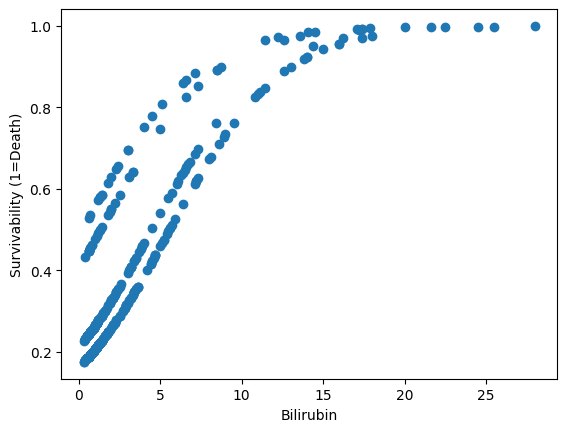

In [30]:
# 2. logistic regression

mapper = {'N': 0, 'S': 1, 'Y': 1} # edema =1 (both types)?
df_cirrhosis['Edema_01'] = df_cirrhosis['Edema'].map(mapper)

mapper = {'Placebo': 0, 'Missing':0 , 'D-penicillamine': 1} # drug=1, missings lumped with placebo
df_cirrhosis['Drug_01'] = df_cirrhosis['Drug'].map(mapper)

mapper = {'C': 0, 'CL': 0, 'D': 1} # death = 1
df_cirrhosis['Status_binary'] = df_cirrhosis['Status'].map(mapper)


x = df_cirrhosis.loc[:, ['Edema_01', 'Drug_01', 'Bilirubin']]
y = df_cirrhosis['Status_binary']
reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg = reg.fit(x,y)
print(pd.DataFrame({'Variable':reg.feature_names_in_, 'Coefficient':reg.coef_[0]}))

# Everything seems to decrease survivability.

plt.scatter(x=df_cirrhosis['Bilirubin'], y=reg.predict_proba(x)[:,1])
plt.xlabel('Bilirubin')
plt.ylabel('Survivability (1=Death)')
plt.show()
# more bilirubin is associated with worse survival predictions

In [32]:
# survival rate and edema

df_cirrhosis.groupby('Edema_01')['Status_binary'].mean()
# presence of edema (resolvable and despite) associated with worse survival outcomes

,Status_binary
Edema_01,
0,0.327684
1,0.703125


<Axes: xlabel='Bilirubin'>

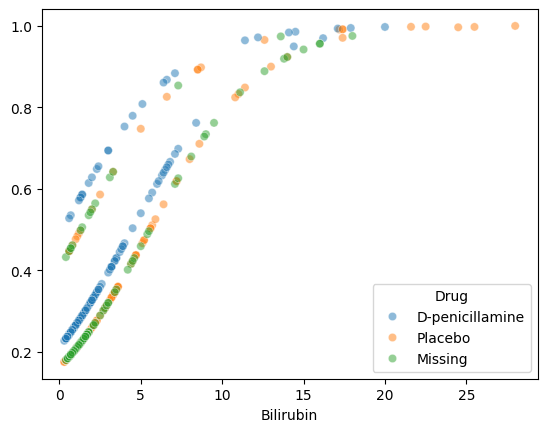

In [33]:
# 3. predicting probabilites

prob = reg.predict_proba(x)
prob = [row[1] for row in prob]

sns.scatterplot(x=df_cirrhosis['Bilirubin'], y=prob,
                hue=df_cirrhosis['Drug'],
                alpha=.5)

# lower values of bilirubin have the lowest death rates.
# based on the scatterplot, the drug doesn't seem to have huge effects on
# survival and is comparable to the placebo

In [35]:
# 4. confusion matrix

y_predict = pd.Series(reg.predict(x))

tab= pd.crosstab(y_predict, df_cirrhosis['Status_binary'])
acc= np.trace(tab)/len(y_predict)
print(f'Confusion matrix:\n {tab}')
print(f'Accuracy: {acc}')

# accuracy is 0.730
# many mistakes where no death is predicted when there was a death;
# less than half of deaths are correctly predicted while most survivals are
# predicted correctly

Confusion matrix:
 Status_binary    0   1
row_0                 
0              232  88
1               25  73
Accuracy: 0.7296650717703349


In [37]:
# 5. linear model

x = df_cirrhosis.loc[:, ['Edema_01', 'Drug_01', 'Bilirubin']]
y = df_cirrhosis['Status_binary']

reg = LinearRegression()
reg = reg.fit(x,y)

y_hat = reg.predict(x)

pd.DataFrame({'Variable':reg.feature_names_in_, 'Coefficient':reg.coef_})

# Convert continuous predictions to binary classes using a threshold (e.g., 0.5)
y_hard_pred= (y_hat >= 0.5).astype(int)

tab= pd.crosstab(y_hard_pred, df_cirrhosis['Status_binary'])
acc= np.trace(tab)/len(y_hard_pred)
print(f'Confusion matrix:\n {tab}')
print(f'Accuracy: {acc}')

# accuracy for the linear model is 0.722 (only very slightly worse than the logistic)
# the linear model is making similar mistakes as the logistic regression (predicting no death when there was death)

Confusion matrix:
 Status_binary    0   1
row_0                 
0              238  97
1               19  64
Accuracy: 0.722488038277512


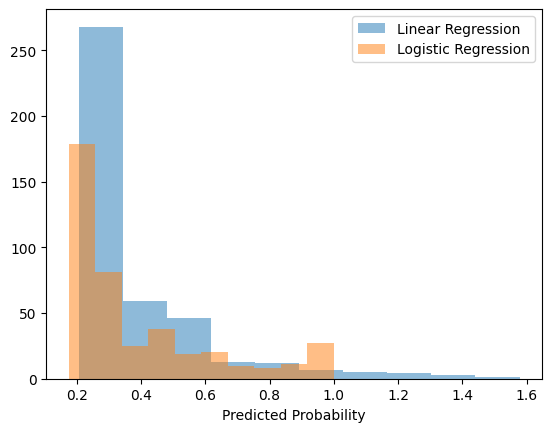

In [38]:
# histograms
plt.hist(x=y_hat, alpha=.5, label='Linear Regression')
plt.hist(x=prob, alpha=.5, label='Logistic Regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

In [41]:
# 6. stage instead

# Drop rows where 'Stage' is NaN... only 6 dropped
df_cirrhosis_cleaned = df_cirrhosis.dropna(subset=['Stage']).copy()

x = df_cirrhosis_cleaned.loc[:, ['Edema_01','Bilirubin']]
y = df_cirrhosis_cleaned['Stage']

reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg = reg.fit(x,y)

hard_predict = pd.Series(reg.predict(x))

tab= pd.crosstab(hard_predict, df_cirrhosis_cleaned['Stage'])
acc= np.trace(tab)/len(hard_predict)
print(f'Confusion matrix:\n {tab}')
print(f'Accuracy: {acc}')

# It is not predicting all stages (only 2 of 4)

Confusion matrix:
 Stage  1.0  2.0  3.0  4.0
row_0                    
3.0     21   76  125  100
4.0      0   16   26   42
Accuracy: 0.08980582524271845


In [43]:
df_cirrhosis_cleaned['Stage'].value_counts()
# Since there are only a few stage 1s and fewer stage 2s compared to 3 & 4,
# 1 & 2 are not being predicted at all, having a negative impact on accuracy.

,count
Stage,
3.0,155
4.0,144
2.0,92
1.0,21


In [44]:
# probabilities
prob = reg.predict_proba(x)
prob
# There are probabilities for each stage for a given prediction.

array([[3.31515798e-04, 5.47322206e-02, 1.98943341e-01, 7.45992923e-01],
       [7.05226581e-02, 2.57339026e-01, 3.99597294e-01, 2.72541022e-01],
       [2.55593517e-02, 1.14612077e-01, 3.02109076e-01, 5.57719495e-01],
       ...,
       [6.10402539e-02, 2.55603342e-01, 4.01799935e-01, 2.81556469e-01],
       [7.68404296e-02, 2.58168251e-01, 3.97945731e-01, 2.67045588e-01],
       [7.90578366e-02, 2.58406439e-01, 3.97337047e-01, 2.65198678e-01]])

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

1.
∂x / ​∂y^​ ​=bk

+1 change in Xk, the prediction changes by bk

2.
∂p^ / ∂Xk = bk*p^(1-p^)

This is similar to part 1 because logistic regression is a linear model and bk shapes how a feature impacts the prediction in both cases. A difference is that, in logistic regression, the effect of a feature varies with x through p^(1-p^), becoming small near 0 or 1 and is largest near 0.5. Part 1 is much simpler.

3.
A one unit change in Xk changes the log-odds ratio by bk.